# Decoding the belief state from an RNN

In [1]:
import os
import numpy as np; np.set_printoptions(linewidth=150)
import torch; torch.set_printoptions(linewidth=150)
from torch import nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pickle

In [2]:
from environment import CliffWalk, InfiniteWalk
from episodes import Episode, collect_episodes, EpisodeCollection
from belief_decoders import NonLinBeliefDecoder, LinBeliefDecoder, decode_training, decode_visualisation, estimate_entropy
from belief_rnn import BeliefRNN, RewardReadout, ValueReadout, NextLatentPredictor, ObsReadout
from train import train, plot_train_losses
from plot_validate import plot_validate

In [3]:
with open("precomputed_values/history_value_st01_ep03.pkl", "rb") as f:
    history_vtable = pickle.load(f)

with open("precomputed_values/state_value_st01_ep03.pkl", "rb") as f:
    value_empirical = pickle.load(f)

### Actual stuff

In [4]:
N, M = 3, 8
cliff = CliffWalk(n=N, m=M, self_transition_prob=0.1, gamma=1.0)
policy = cliff.get_optimal_policy(epsilon=0.3)

# Collect episodes from the environment using the target policy
episode_list = collect_episodes(cliff, policy, num_episodes=20000)

episodes = EpisodeCollection(episode_list)
print(np.mean(episodes.ep_lengths))

print("Empirical State Value function:")
print(np.flip(value_empirical.reshape((cliff.n, cliff.m)), axis=0))

11.84135
Empirical State Value function:
[[  1.86   2.1    2.55   3.02   3.53   4.32   6.13   9.35]
 [ -0.87  -1.18  -0.7   -0.13   0.46   1.08   2.91   9.5 ]
 [ -1.34 -10.   -10.   -10.   -10.   -10.   -10.    10.  ]]


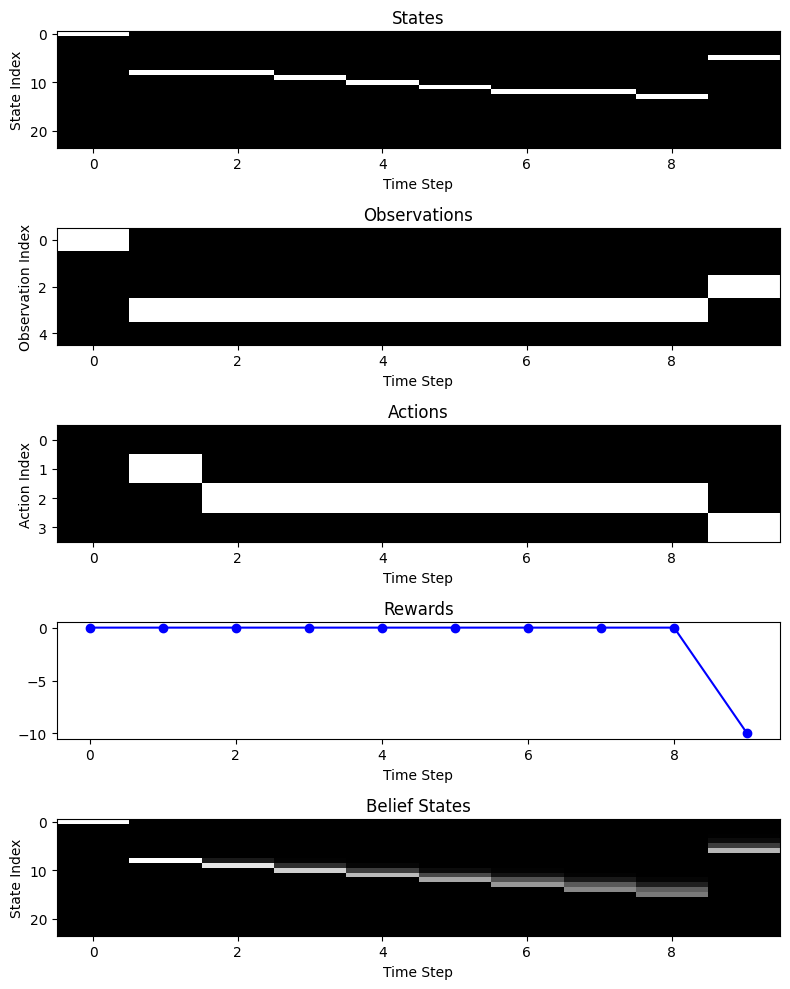

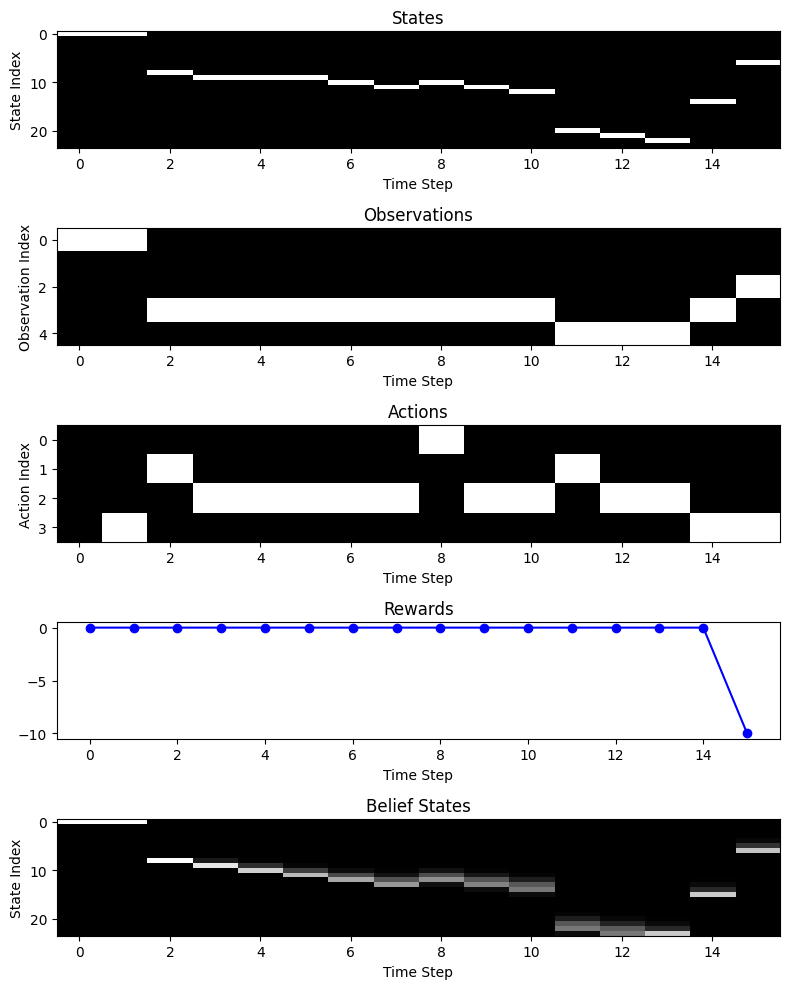

In [5]:
test_episodes = []

# Get an out of sample test episode to validate the model
test_ep_len = 0
while test_ep_len < 10:
    test_episode = collect_episodes(cliff, policy, num_episodes=1)[0]
    test_ep_len = len(test_episode.history)
test_episode.render()
test_episodes.append(test_episode)

test_ep_len = 0
i = 0
while test_ep_len < 10:
    test_episode = episodes.episodes[i]
    test_ep_len = len(test_episode.history)
    i += 1
test_episode.render()
test_episodes.append(test_episode)

Linear Values:
[ -1.34  -0.87  -1.15  -0.79  -0.3    0.23   0.77   1.97   5.77 -10.  ]
History Values:
[-1.33, -0.49, -0.71, -0.32, 0.24, 0.9, 1.65, 2.51, 3.5, -10.0]
Predicted Values:
[-0.02 -0.05 -0.06 -0.08 -0.09 -0.1  -0.11 -0.11 -0.11 -0.05]


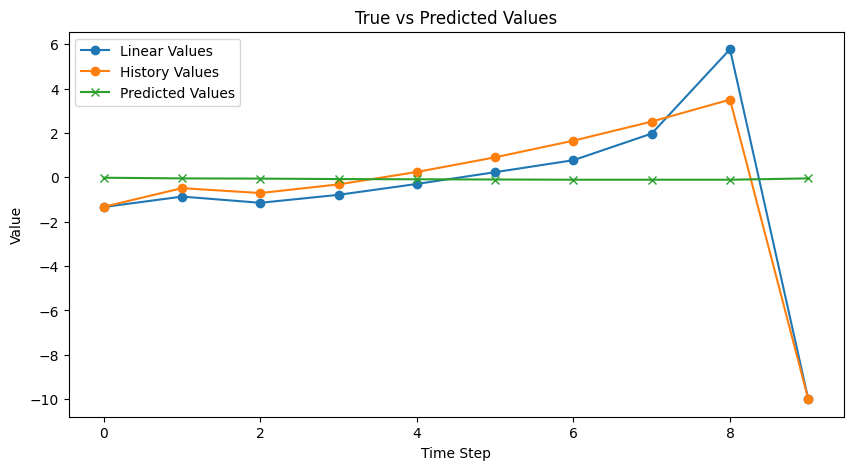

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[-0.01 -0.01  0.    0.    0.01  0.01  0.01  0.01  0.01 -0.02]


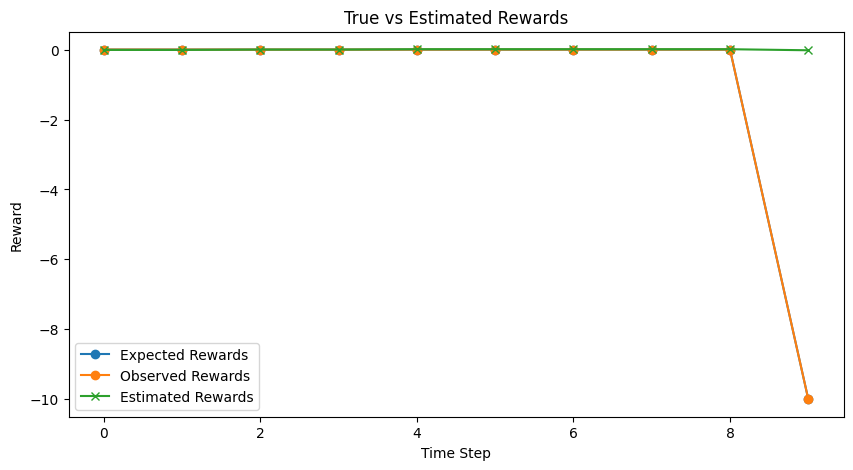

True Expected Rewards:
[ 0.    0.    0.    0.    0.    0.    0.    0.   -0.39]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[0.06 0.1  0.11 0.12 0.12 0.13 0.13 0.13 0.09]


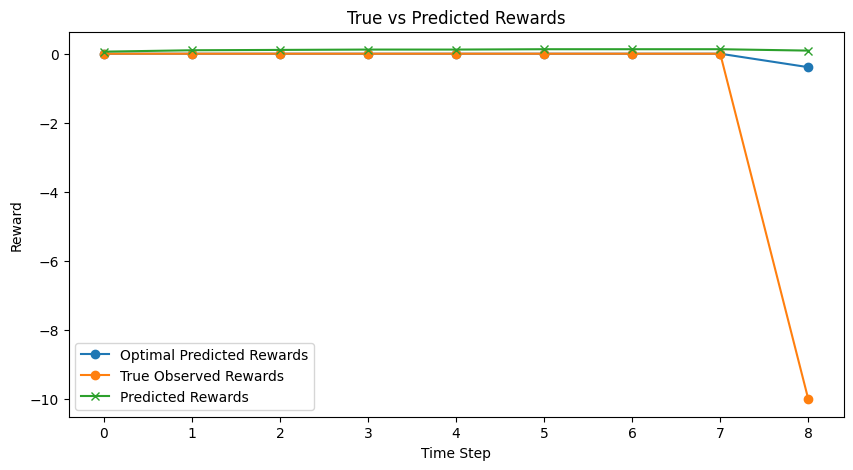

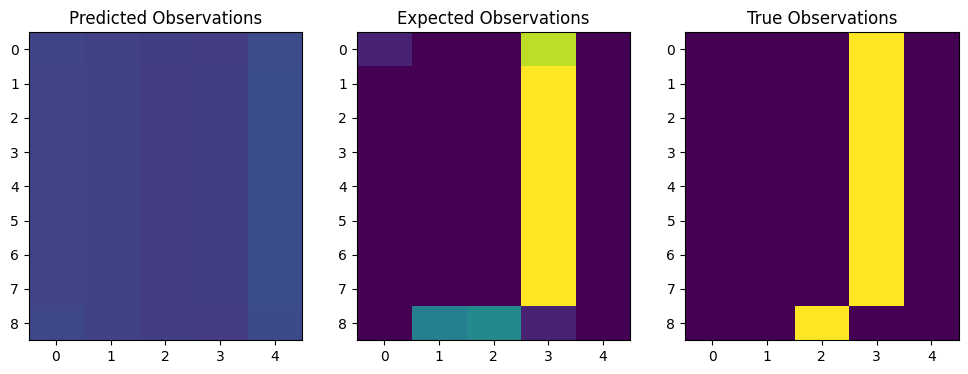

Linear Values:
[ -1.34  -1.34  -0.87  -1.15  -0.79  -0.3    0.23   0.77   0.23   0.84   2.24   5.29   7.3    8.59   8.04 -10.  ]
History Values:
[-1.33, -1.4, -0.59, -0.79, -0.44, 0.14, 0.83, 1.54, 0.34, 0.9, 2.07, 3.1, 3.64, 3.33, 7.14, nan]
Predicted Values:
[-0.02 -0.06 -0.06 -0.07 -0.08 -0.09 -0.1  -0.11 -0.09 -0.09 -0.1  -0.05 -0.03 -0.02 -0.07 -0.04]


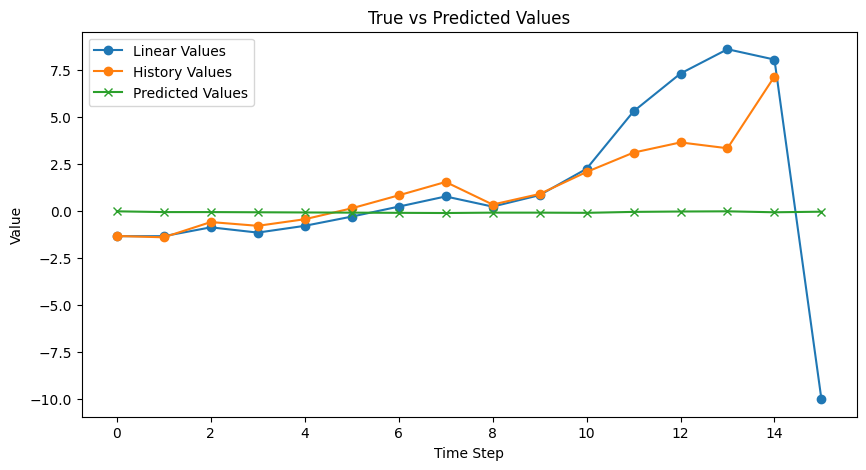

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[-0.01 -0.03 -0.02 -0.    0.    0.01  0.01  0.01 -0.    0.01  0.01 -0.02 -0.04 -0.05 -0.03 -0.04]


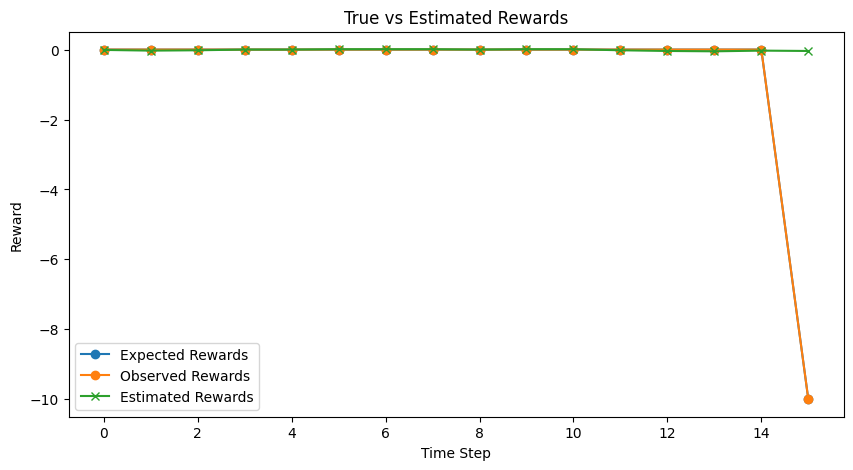

True Expected Rewards:
[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   5.26]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[0.06 0.06 0.11 0.12 0.12 0.12 0.13 0.09 0.12 0.12 0.08 0.11 0.11 0.07 0.07]


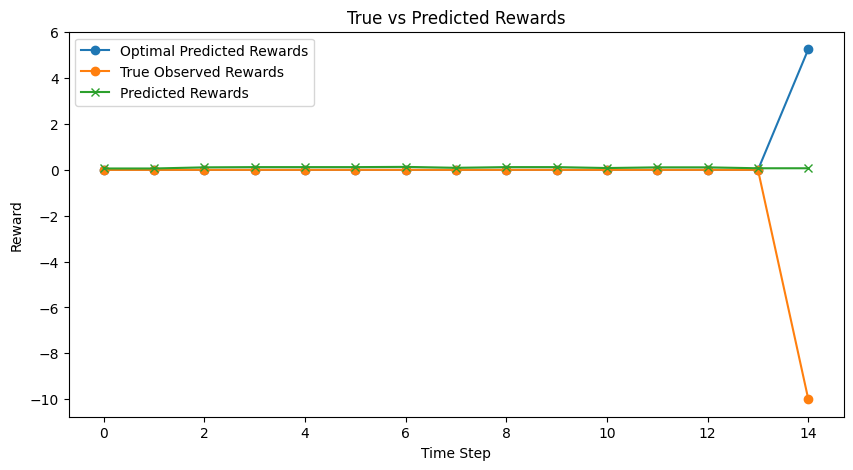

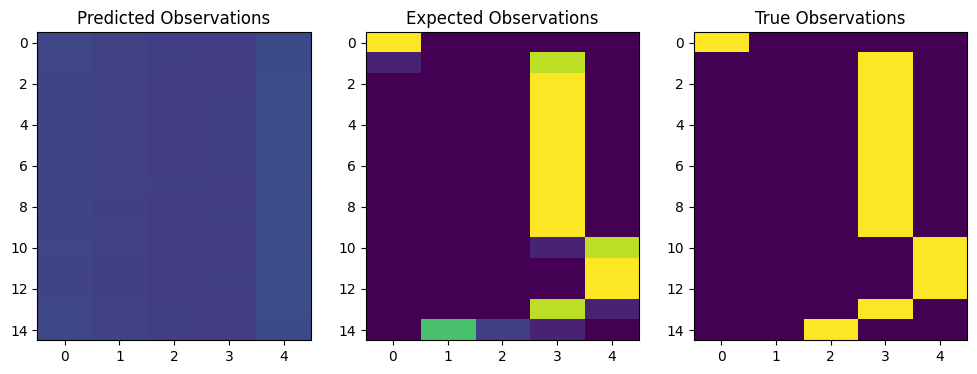

In [6]:
RNN_HIDDEN = 64

belief_model = BeliefRNN(input_dim=episodes.H, latent_dim=RNN_HIDDEN)
value_model = ValueReadout(RNN_HIDDEN)
reward_model = RewardReadout(RNN_HIDDEN)
pred_model = NextLatentPredictor(RNN_HIDDEN)
obs_model = ObsReadout(RNN_HIDDEN, 5)

models = belief_model, value_model, reward_model, pred_model, obs_model

plot_validate(models, test_episodes, cliff, history_vtable, value_empirical)

Epoch 1 l TD: 10.59, l R est: 0.0, l R pred: 4.4, l O pred: 1.27, Total: 16.26     
Epoch 50 l TD: 7.8, l R est: 0.01, l R pred: 4.7, l O pred: 1.33, Total: 13.84        
Epoch 100 l TD: 8.36, l R est: 0.01, l R pred: 4.54, l O pred: 1.3, Total: 14.21     
Epoch 150 l TD: 8.19, l R est: 0.01, l R pred: 4.6, l O pred: 1.37, Total: 14.17      
Epoch 200 l TD: 7.99, l R est: 0.0, l R pred: 4.57, l O pred: 1.31, Total: 13.87      
Epoch 250 l TD: 8.39, l R est: 0.01, l R pred: 4.55, l O pred: 1.32, Total: 14.27     
Epoch 300 l TD: 8.78, l R est: 0.0, l R pred: 4.56, l O pred: 1.32, Total: 14.66      
Epoch 350 l TD: 8.29, l R est: 0.01, l R pred: 4.37, l O pred: 1.3, Total: 13.97      
Epoch 400 l TD: 8.47, l R est: 0.0, l R pred: 4.57, l O pred: 1.33, Total: 14.37      
Epoch 450 l TD: 8.55, l R est: 0.0, l R pred: 4.69, l O pred: 1.35, Total: 14.59      
Epoch 500 l TD: 8.25, l R est: 0.0, l R pred: 4.34, l O pred: 1.26, Total: 13.85      
Linear Values:
[ -1.34  -0.87  -1.15  -0.79  -0

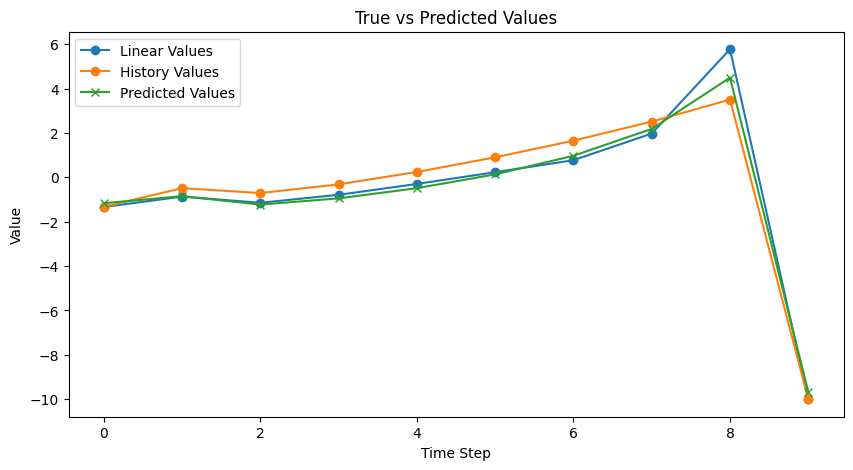

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[-1.000e-02 -3.000e-02 -3.000e-02 -4.000e-02 -3.000e-02 -3.000e-02 -2.000e-02 -0.000e+00  2.000e-02 -1.004e+01]


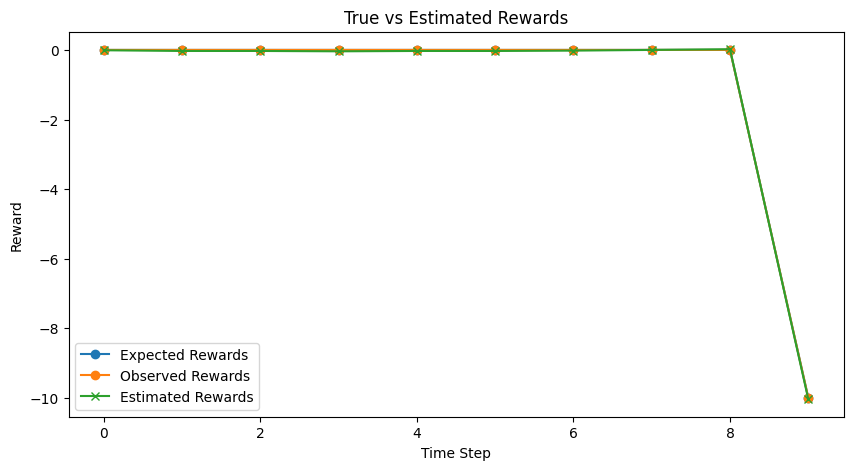

True Expected Rewards:
[ 0.    0.    0.    0.    0.    0.    0.    0.   -0.39]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[ 0.   -0.01  0.   -0.02  0.   -0.   -0.02 -0.01  0.  ]


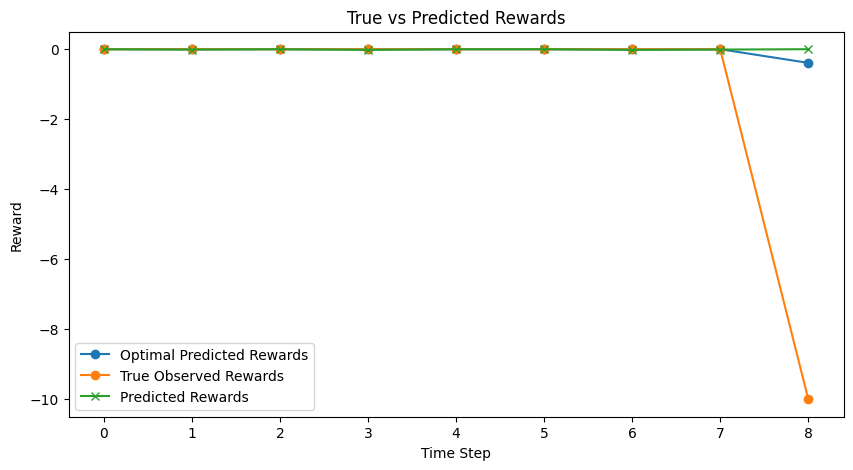

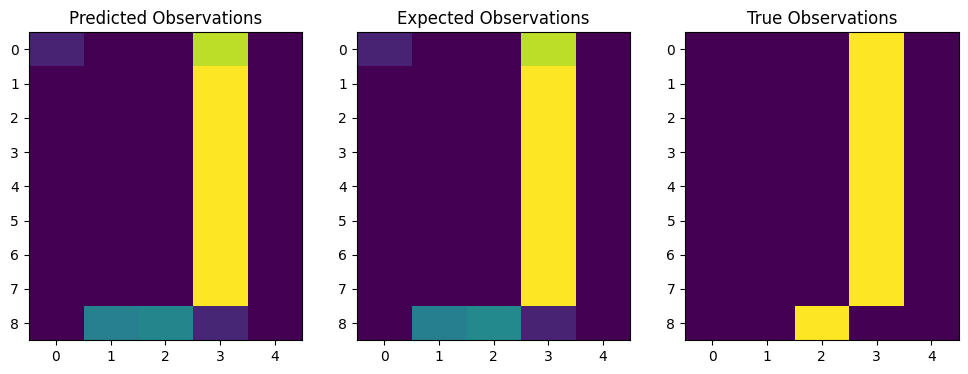

Linear Values:
[ -1.34  -1.34  -0.87  -1.15  -0.79  -0.3    0.23   0.77   0.23   0.84   2.24   5.29   7.3    8.59   8.04 -10.  ]
History Values:
[-1.33, -1.4, -0.59, -0.79, -0.44, 0.14, 0.83, 1.54, 0.34, 0.9, 2.07, 3.1, 3.64, 3.33, 7.14, nan]
Predicted Values:
[-1.17 -1.32 -0.78 -1.2  -0.93 -0.48  0.14  0.98 -0.01  0.91  2.15  4.48  5.71  7.67  8.   -8.87]


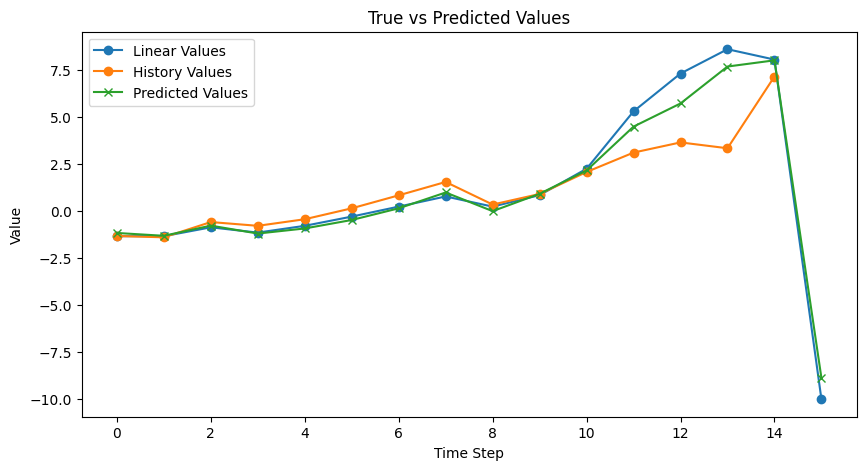

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[-0.01  0.09  0.04 -0.06 -0.06 -0.03 -0.03 -0.02 -0.04  0.01  0.03  0.06  0.01 -0.01  0.04 -9.92]


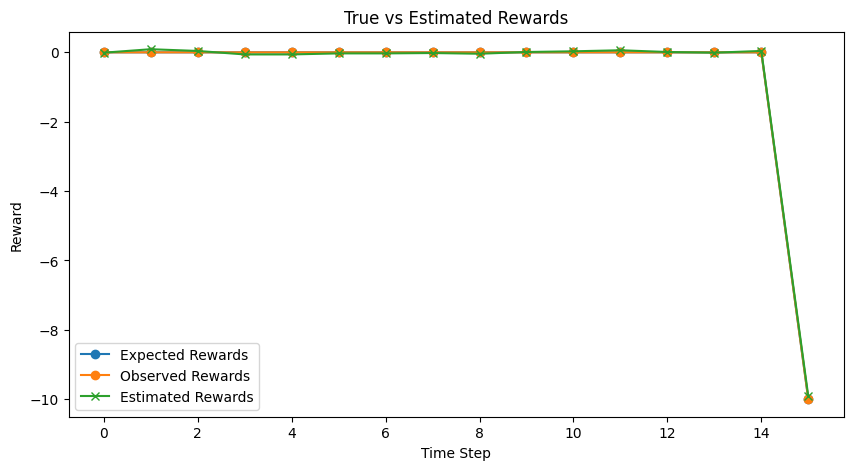

True Expected Rewards:
[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   5.26]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[-0.11  0.    0.01 -0.04  0.03  0.02  0.    0.05 -0.07 -0.09  0.04 -0.03  0.11 -0.01  5.53]


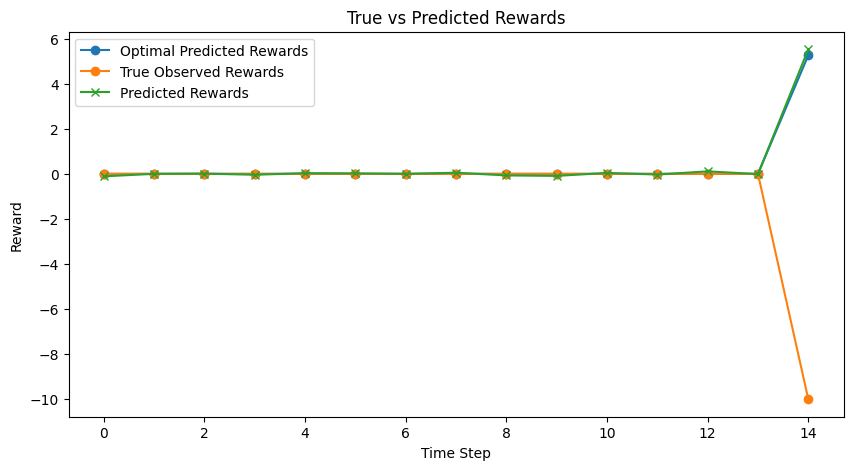

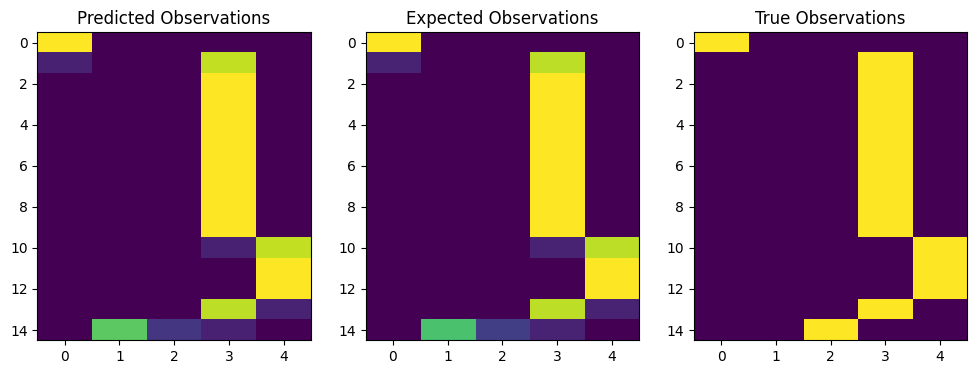

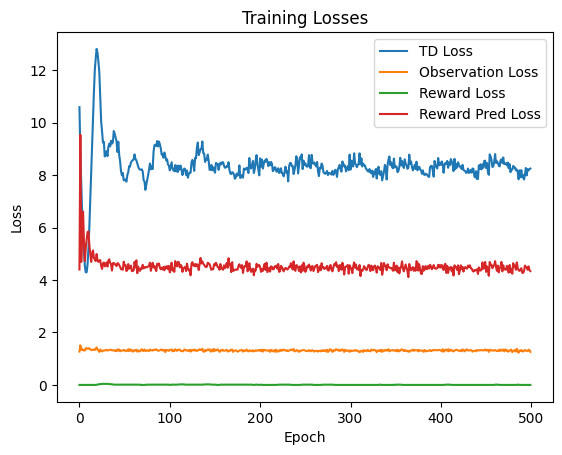

Epoch 1 l TD: 8.28, l R est: 0.0, l R pred: 4.38, l O pred: 1.29, Total: 13.95     
Epoch 50 l TD: 9.2, l R est: 0.01, l R pred: 4.35, l O pred: 1.3, Total: 14.86       
Epoch 100 l TD: 8.87, l R est: 0.01, l R pred: 4.37, l O pred: 1.24, Total: 14.49     
Epoch 150 l TD: 8.28, l R est: 0.0, l R pred: 4.53, l O pred: 1.33, Total: 14.14      
Epoch 200 l TD: 8.17, l R est: 0.0, l R pred: 4.46, l O pred: 1.32, Total: 13.95     
Epoch 250 l TD: 8.42, l R est: 0.0, l R pred: 4.57, l O pred: 1.29, Total: 14.28     
Epoch 300 l TD: 7.93, l R est: 0.0, l R pred: 4.28, l O pred: 1.26, Total: 13.47     
Epoch 350 l TD: 8.57, l R est: 0.0, l R pred: 4.64, l O pred: 1.32, Total: 14.53     
Epoch 400 l TD: 8.24, l R est: 0.0, l R pred: 4.25, l O pred: 1.31, Total: 13.8      
Epoch 450 l TD: 8.44, l R est: 0.0, l R pred: 4.58, l O pred: 1.33, Total: 14.35     
Epoch 500 l TD: 8.54, l R est: 0.0, l R pred: 4.39, l O pred: 1.29, Total: 14.22     
Linear Values:
[ -1.34  -0.87  -1.15  -0.79  -0.3    0

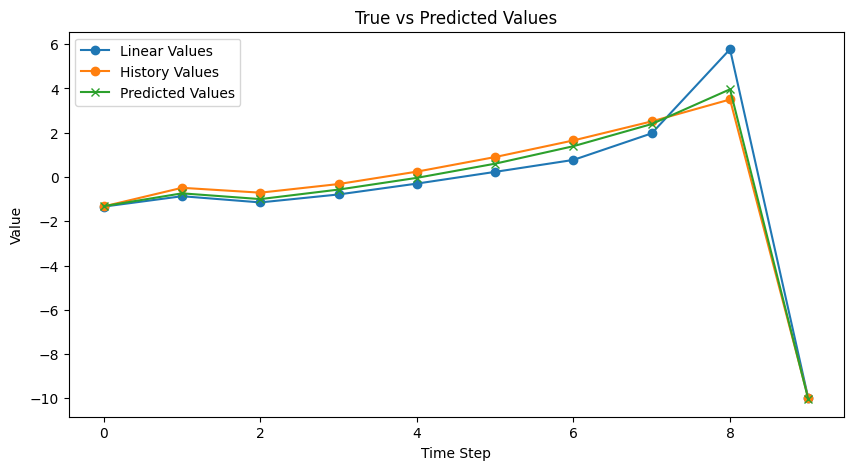

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[-1.000e-02 -2.000e-02 -2.000e-02  1.000e-02  0.000e+00 -0.000e+00  1.000e-02  2.000e-02  3.000e-02 -1.002e+01]


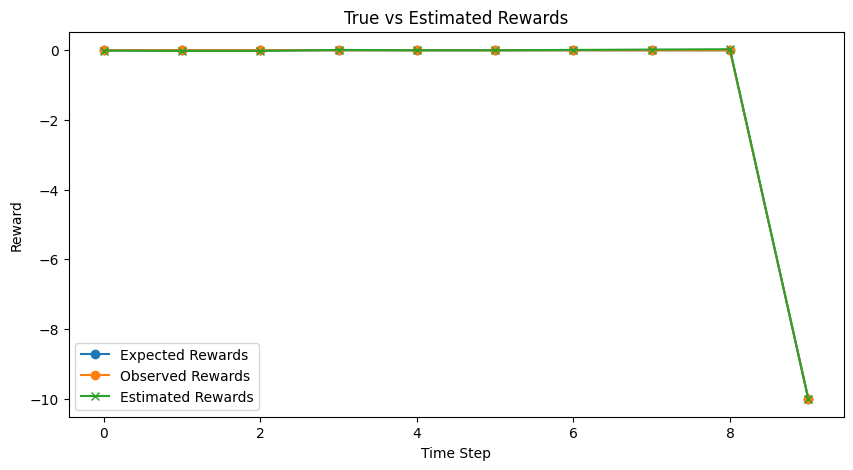

True Expected Rewards:
[ 0.    0.    0.    0.    0.    0.    0.    0.   -0.39]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[ 0.05  0.08  0.17  0.14  0.18  0.18  0.16  0.18 -0.38]


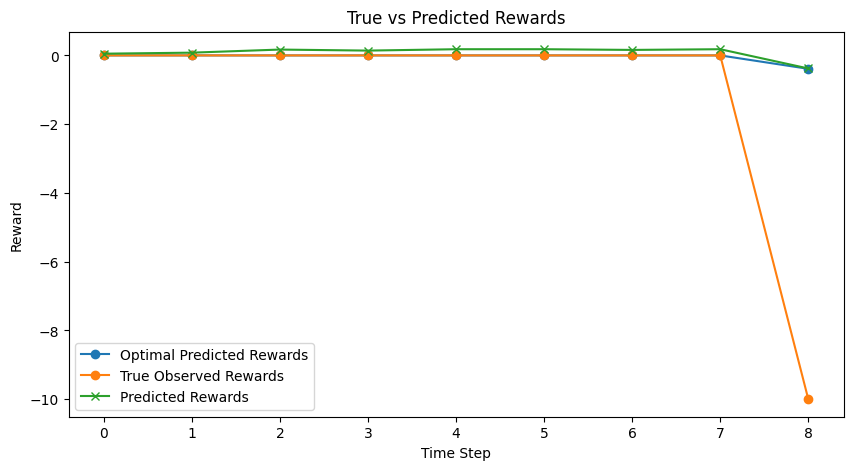

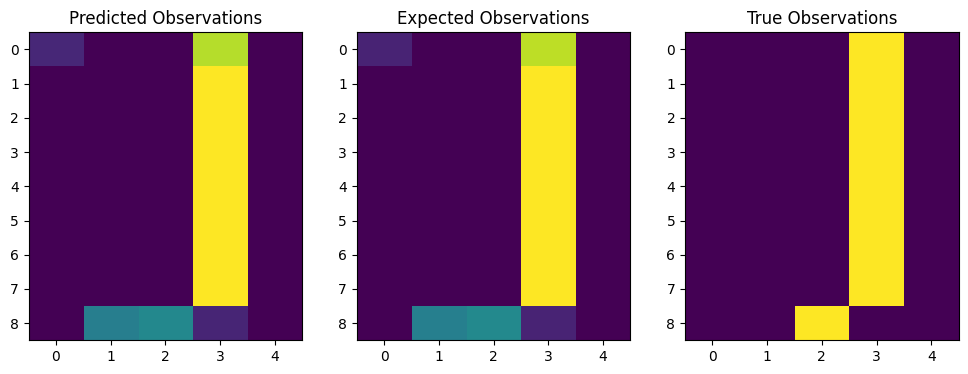

Linear Values:
[ -1.34  -1.34  -0.87  -1.15  -0.79  -0.3    0.23   0.77   0.23   0.84   2.24   5.29   7.3    8.59   8.04 -10.  ]
History Values:
[-1.33, -1.4, -0.59, -0.79, -0.44, 0.14, 0.83, 1.54, 0.34, 0.9, 2.07, 3.1, 3.64, 3.33, 7.14, nan]
Predicted Values:
[-1.32 -1.49 -0.69 -0.94 -0.56 -0.03  0.59  1.36  0.38  1.2   2.21  5.3   6.11  7.61  6.52 -9.96]


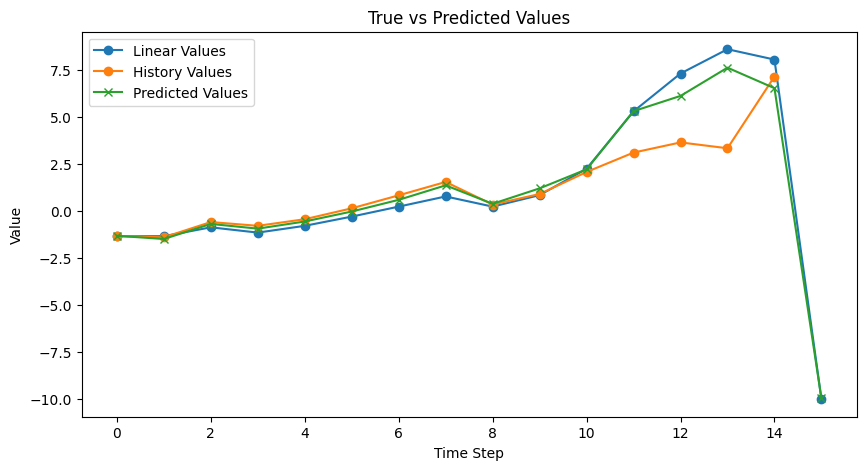

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[-0.01  0.06  0.04 -0.04 -0.01  0.   -0.    0.01 -0.02  0.01  0.05  0.06  0.03  0.02  0.04 -9.93]


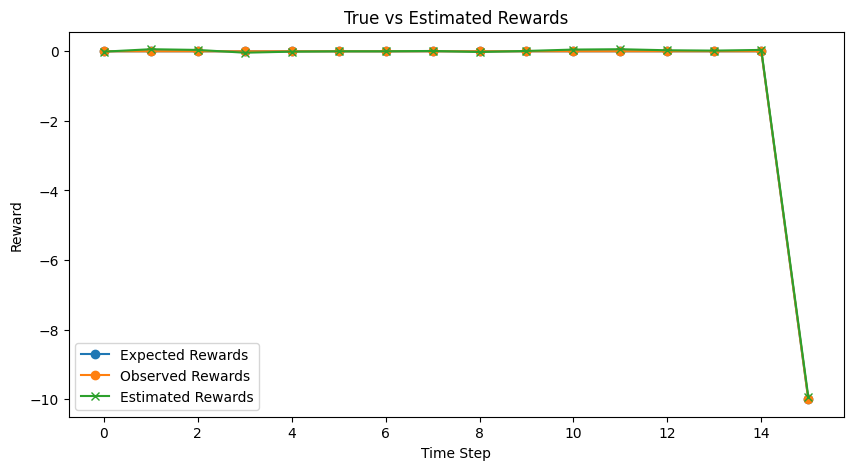

True Expected Rewards:
[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   5.26]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[0.04 0.11 0.08 0.12 0.19 0.19 0.18 0.25 0.1  0.08 0.23 0.07 0.2  0.24 4.75]


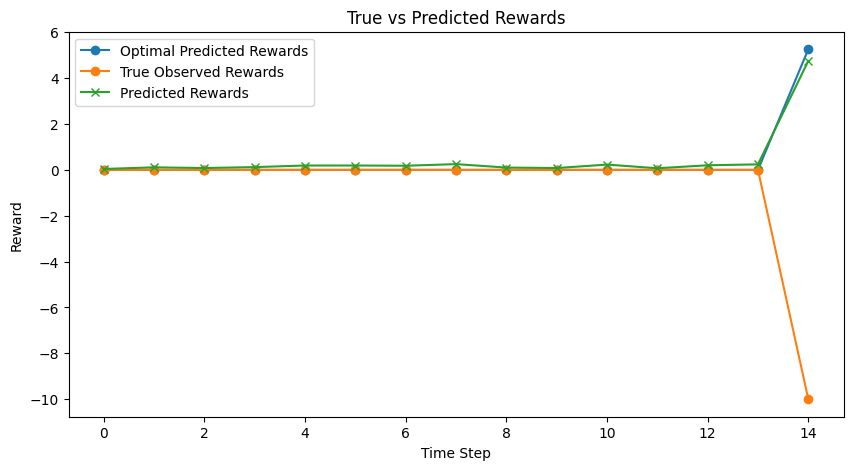

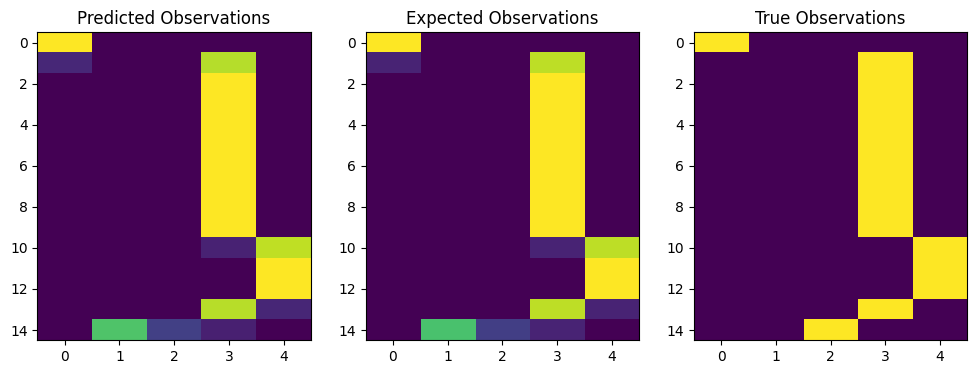

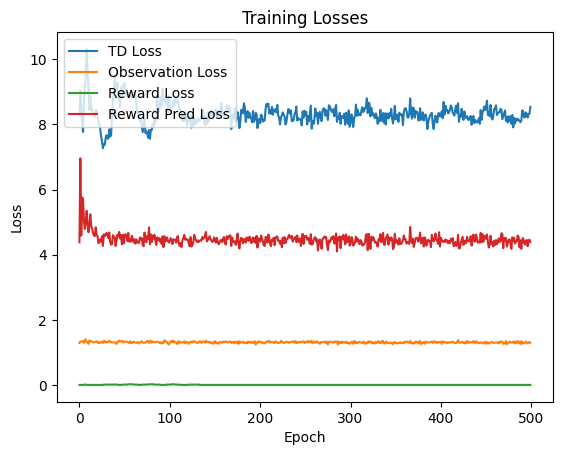

Epoch 1 l TD: 8.26, l R est: 0.0, l R pred: 4.32, l O pred: 1.31, Total: 13.89     
Epoch 50 l TD: 8.71, l R est: 0.0, l R pred: 4.5, l O pred: 1.3, Total: 14.51       
Epoch 100 l TD: 8.31, l R est: 0.0, l R pred: 4.53, l O pred: 1.31, Total: 14.15     
Epoch 150 l TD: 8.68, l R est: 0.0, l R pred: 4.68, l O pred: 1.34, Total: 14.7       
Epoch 200 l TD: 8.57, l R est: 0.0, l R pred: 4.32, l O pred: 1.29, Total: 14.18      
Epoch 250 l TD: 8.67, l R est: 0.0, l R pred: 4.49, l O pred: 1.34, Total: 14.5       
Epoch 300 l TD: 8.39, l R est: 0.0, l R pred: 4.36, l O pred: 1.27, Total: 14.02     
Epoch 350 l TD: 9.0, l R est: 0.0, l R pred: 4.7, l O pred: 1.31, Total: 15.01       
Epoch 400 l TD: 8.06, l R est: 0.0, l R pred: 4.35, l O pred: 1.3, Total: 13.71      
Epoch 450 l TD: 8.06, l R est: 0.0, l R pred: 4.35, l O pred: 1.29, Total: 13.7      
Epoch 500 l TD: 8.09, l R est: 0.0, l R pred: 4.54, l O pred: 1.31, Total: 13.94     
Linear Values:
[ -1.34  -0.87  -1.15  -0.79  -0.3    0

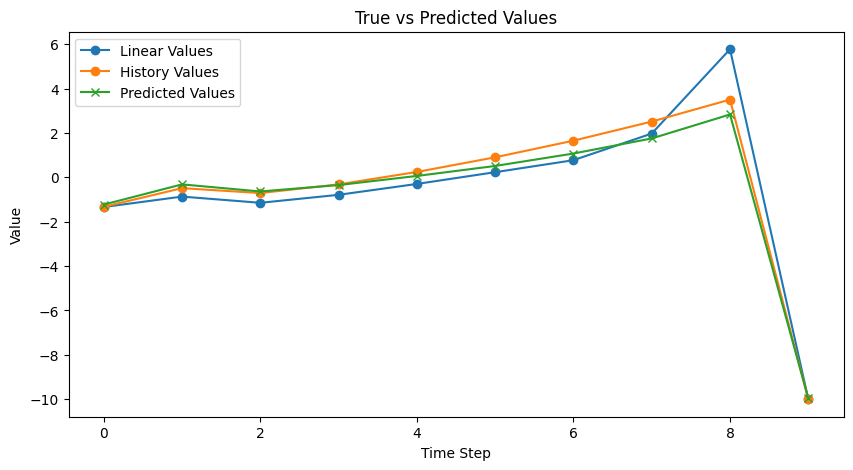

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[ 1.000e-02  4.000e-02 -1.000e-02 -2.000e-02 -4.000e-02 -4.000e-02 -5.000e-02 -4.000e-02 -4.000e-02 -1.008e+01]


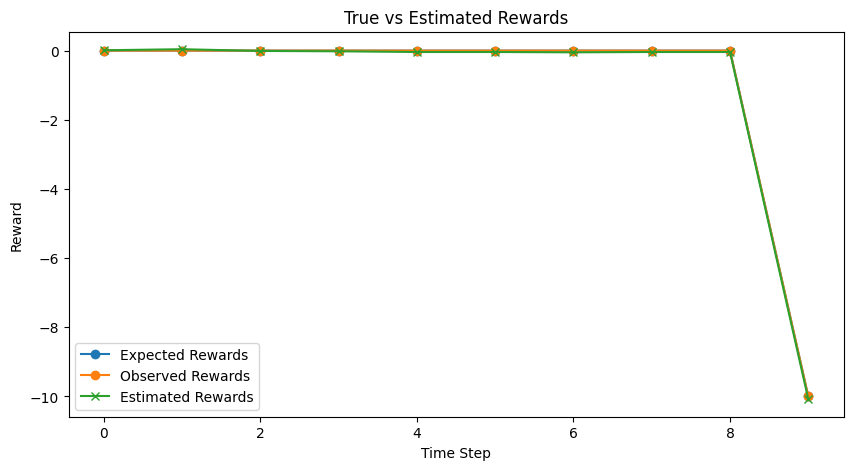

True Expected Rewards:
[ 0.    0.    0.    0.    0.    0.    0.    0.   -0.39]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[-0.07 -0.02 -0.02 -0.02  0.02 -0.   -0.02 -0.02 -0.63]


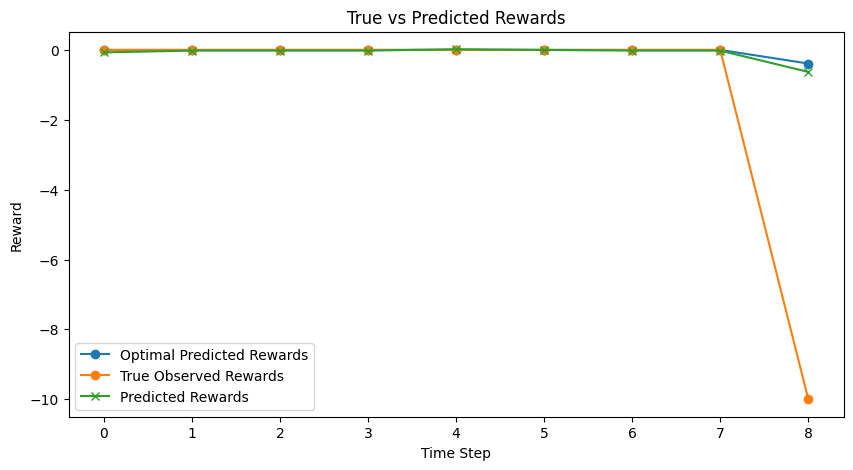

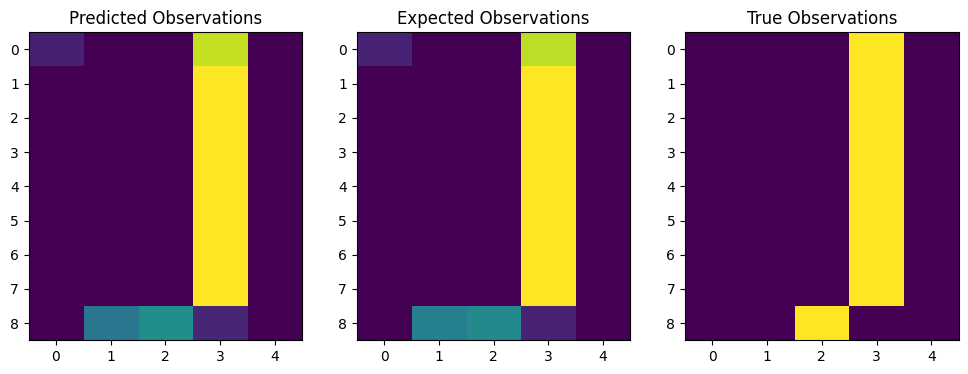

Linear Values:
[ -1.34  -1.34  -0.87  -1.15  -0.79  -0.3    0.23   0.77   0.23   0.84   2.24   5.29   7.3    8.59   8.04 -10.  ]
History Values:
[-1.33, -1.4, -0.59, -0.79, -0.44, 0.14, 0.83, 1.54, 0.34, 0.9, 2.07, 3.1, 3.64, 3.33, 7.14, nan]
Predicted Values:
[-1.23 -1.25 -0.17 -0.55 -0.34  0.05  0.5   1.04  0.44  0.96  1.65  4.12  4.51  5.51  5.59 -9.86]


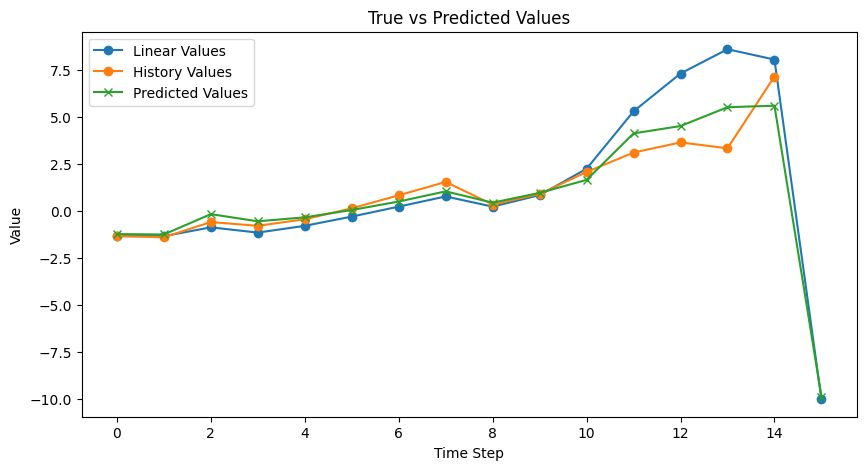

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[ 0.01  0.12  0.11 -0.03 -0.04 -0.04 -0.04 -0.05 -0.06 -0.04 -0.01 -0.01 -0.1  -0.11 -0.04 -9.91]


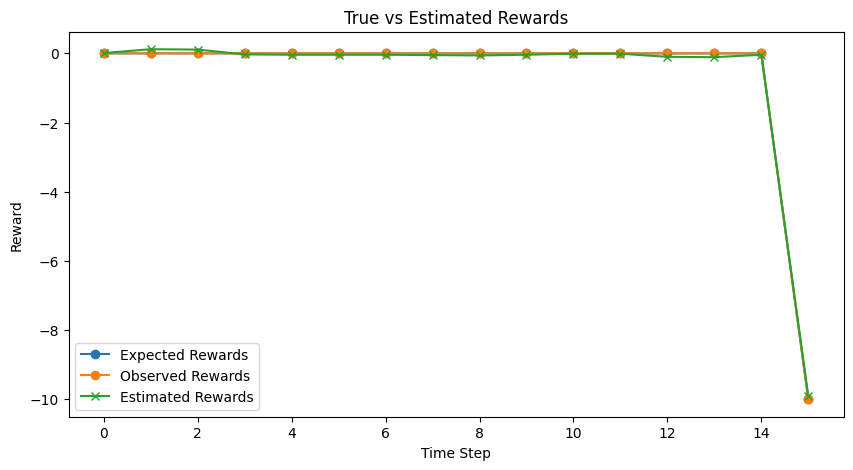

True Expected Rewards:
[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   5.26]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[-0.17 -0.05 -0.03 -0.07  0.03  0.04  0.    0.1  -0.1  -0.08  0.07  0.07  0.14 -0.1   5.09]


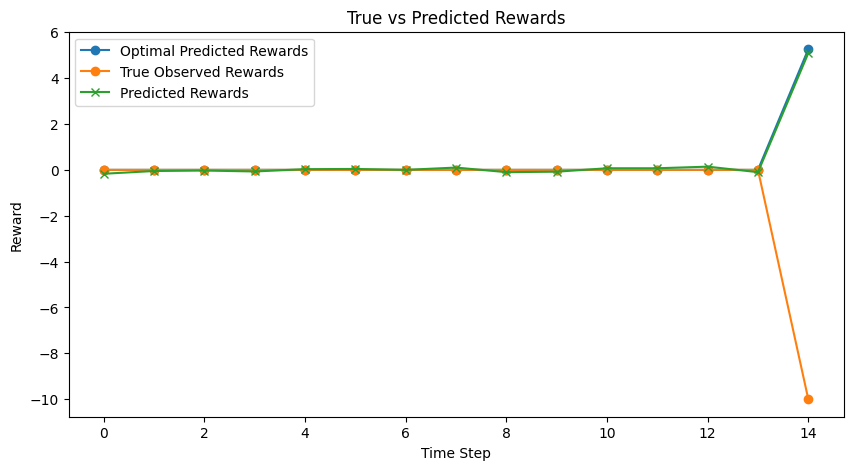

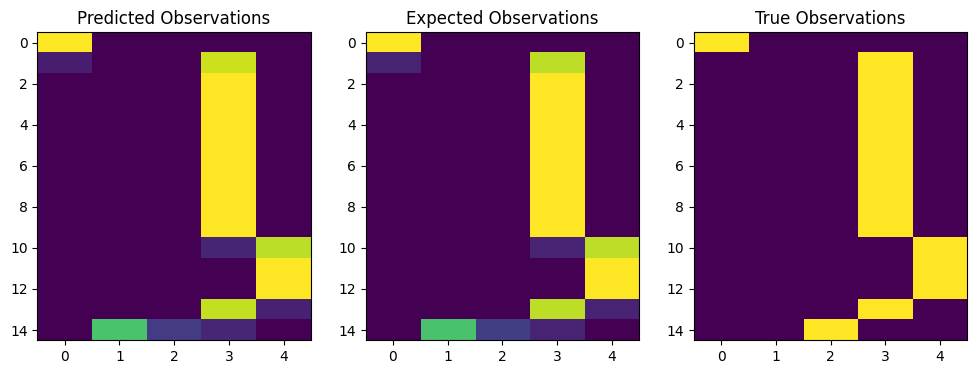

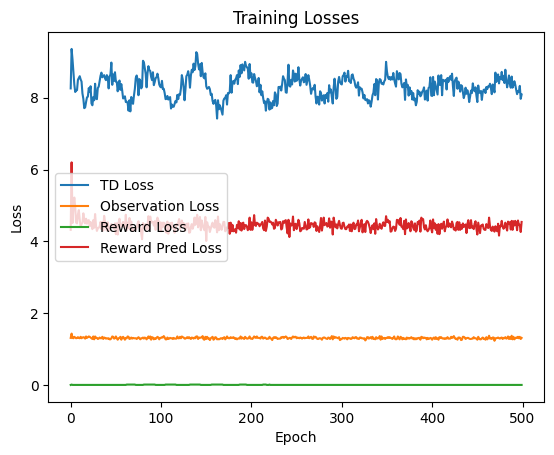

Epoch 1 l TD: 7.91, l R est: 0.0, l R pred: 4.67, l O pred: 1.34, Total: 13.92     
Epoch 50 l TD: 8.42, l R est: 0.0, l R pred: 4.66, l O pred: 1.34, Total: 14.42     
Epoch 100 l TD: 8.08, l R est: 0.0, l R pred: 4.45, l O pred: 1.32, Total: 13.85     
Epoch 150 l TD: 8.16, l R est: 0.0, l R pred: 4.47, l O pred: 1.31, Total: 13.94     
Epoch 200 l TD: 8.59, l R est: 0.0, l R pred: 4.5, l O pred: 1.31, Total: 14.4       
Epoch 250 l TD: 8.19, l R est: 0.0, l R pred: 4.5, l O pred: 1.29, Total: 13.98      
Epoch 300 l TD: 8.54, l R est: 0.0, l R pred: 4.56, l O pred: 1.33, Total: 14.43     
Epoch 350 l TD: 8.2, l R est: 0.0, l R pred: 4.35, l O pred: 1.29, Total: 13.84      
Epoch 400 l TD: 8.17, l R est: 0.0, l R pred: 4.43, l O pred: 1.34, Total: 13.94     
Epoch 450 l TD: 8.14, l R est: 0.0, l R pred: 4.36, l O pred: 1.3, Total: 13.8       
Epoch 500 l TD: 7.89, l R est: 0.0, l R pred: 4.45, l O pred: 1.29, Total: 13.63     
Linear Values:
[ -1.34  -0.87  -1.15  -0.79  -0.3    0.23

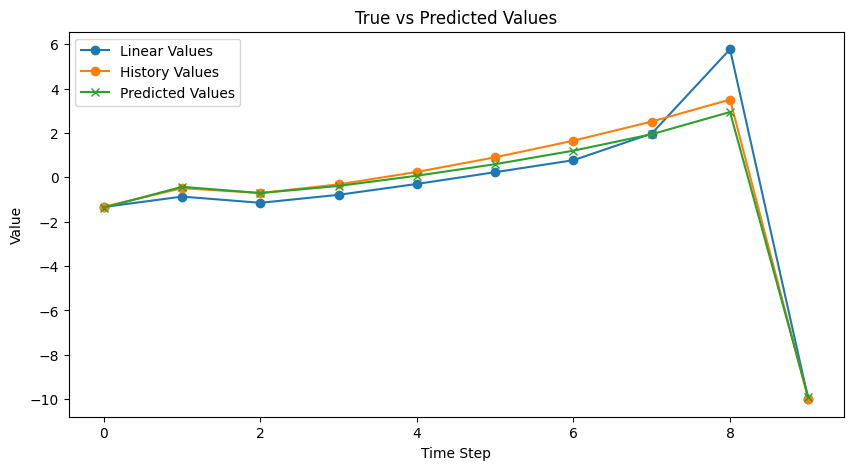

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[-0.000e+00  1.000e-02 -1.000e-02 -1.000e-02 -2.000e-02 -2.000e-02 -2.000e-02 -2.000e-02 -2.000e-02 -1.005e+01]


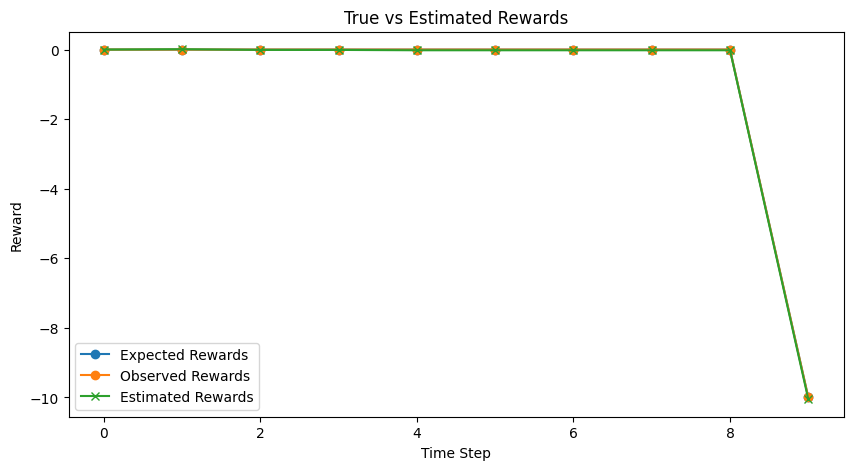

True Expected Rewards:
[ 0.    0.    0.    0.    0.    0.    0.    0.   -0.39]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[-0.07 -0.04 -0.04 -0.07 -0.03 -0.09 -0.13 -0.13 -1.38]


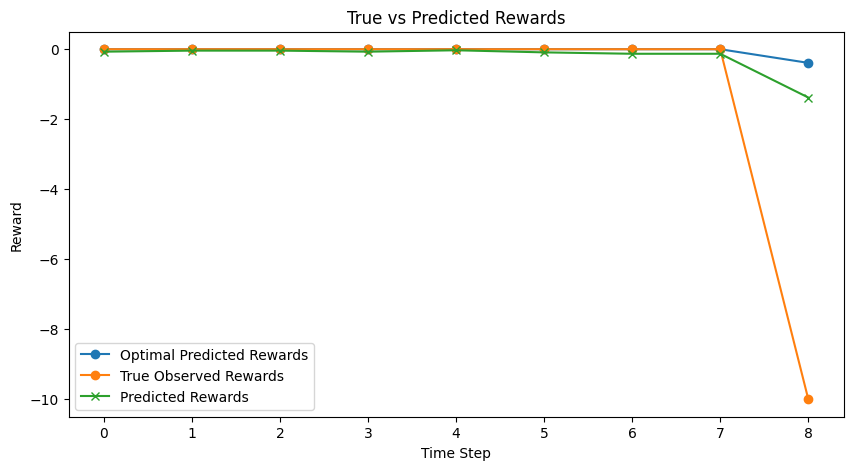

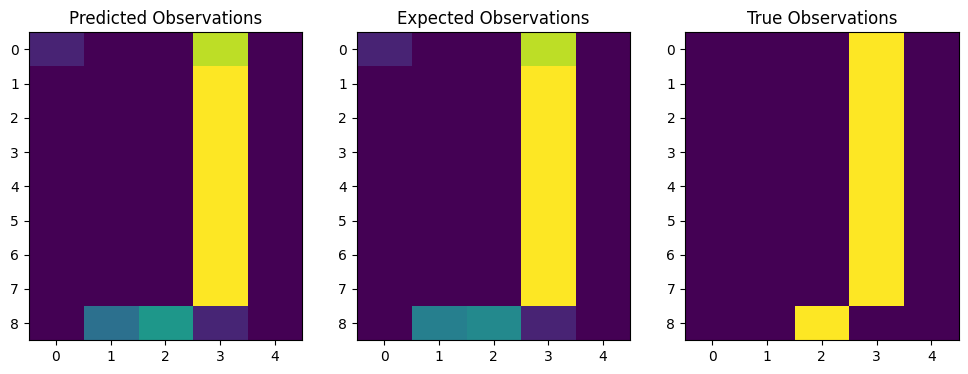

Linear Values:
[ -1.34  -1.34  -0.87  -1.15  -0.79  -0.3    0.23   0.77   0.23   0.84   2.24   5.29   7.3    8.59   8.04 -10.  ]
History Values:
[-1.33, -1.4, -0.59, -0.79, -0.44, 0.14, 0.83, 1.54, 0.34, 0.9, 2.07, 3.1, 3.64, 3.33, 7.14, nan]
Predicted Values:
[-1.37 -1.38 -0.3  -0.62 -0.36  0.08  0.58  1.18  0.37  1.    1.78  4.25  4.6   5.63  5.63 -9.84]


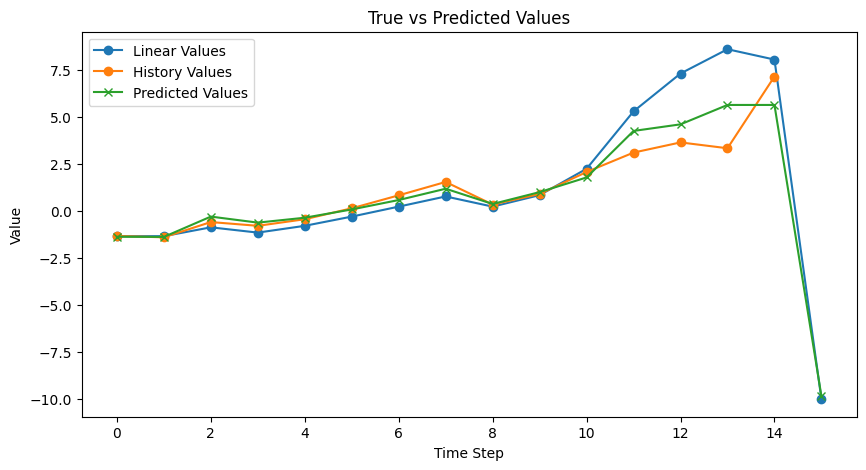

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[-0.    0.06  0.06 -0.03 -0.03 -0.02 -0.03 -0.03 -0.06 -0.04  0.02  0.   -0.06 -0.06  0.01 -9.9 ]


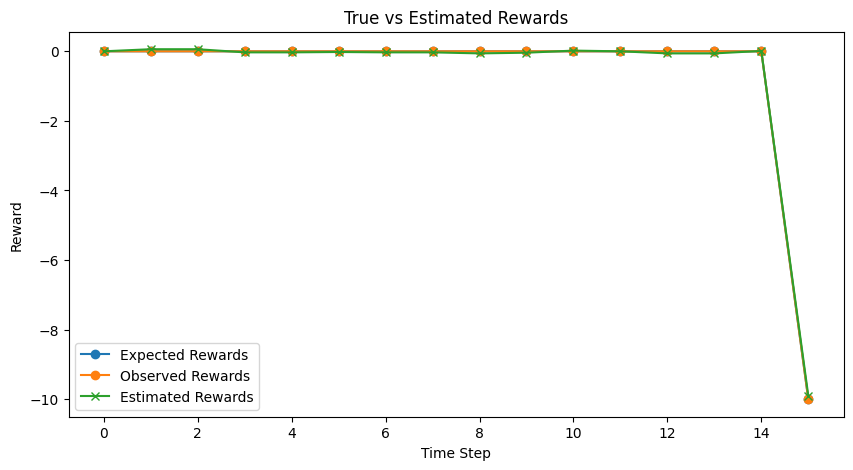

True Expected Rewards:
[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   5.26]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[-0.14 -0.04 -0.02 -0.07 -0.02 -0.03 -0.09 -0.   -0.08 -0.2  -0.02 -0.03  0.03 -0.14  4.61]


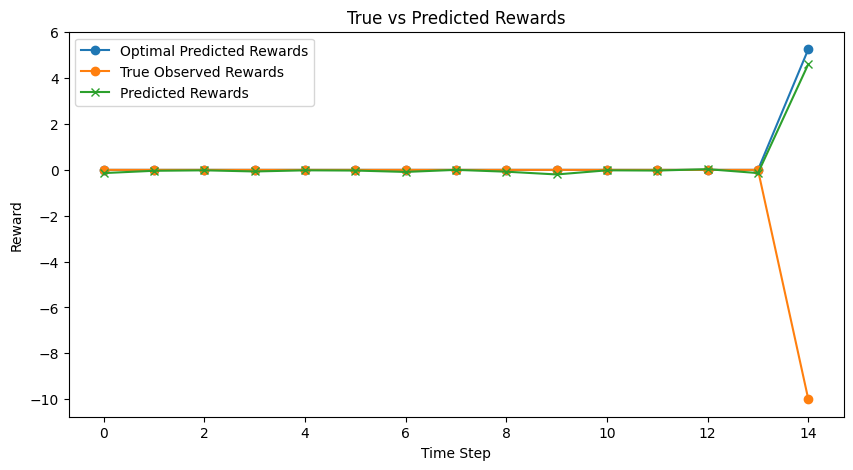

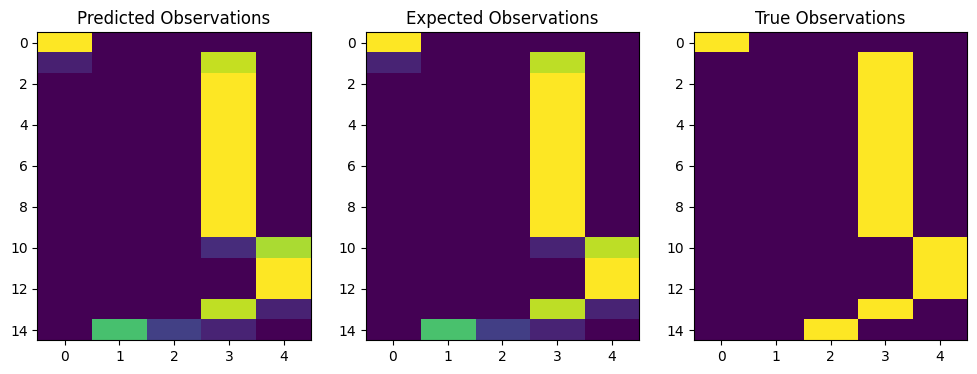

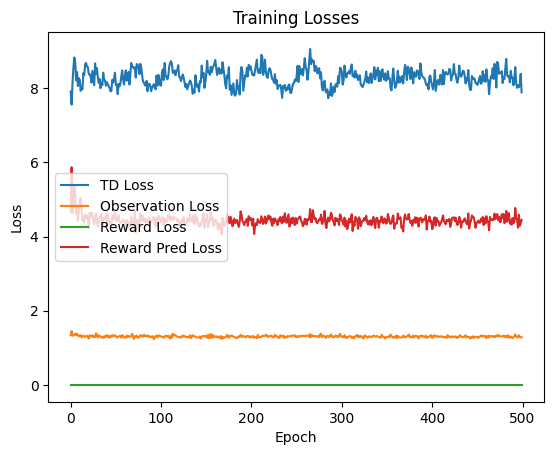

Epoch 1 l TD: 8.09, l R est: 0.0, l R pred: 4.34, l O pred: 1.25, Total: 13.68     
Epoch 50 l TD: 8.18, l R est: 0.0, l R pred: 4.47, l O pred: 1.31, Total: 13.96     
Epoch 100 l TD: 8.47, l R est: 0.0, l R pred: 4.42, l O pred: 1.32, Total: 14.21     
Epoch 150 l TD: 7.91, l R est: 0.0, l R pred: 4.43, l O pred: 1.32, Total: 13.66     
Epoch 200 l TD: 8.53, l R est: 0.0, l R pred: 4.63, l O pred: 1.31, Total: 14.47     
Epoch 250 l TD: 8.54, l R est: 0.0, l R pred: 4.57, l O pred: 1.35, Total: 14.46     
Epoch 300 l TD: 8.3, l R est: 0.0, l R pred: 4.49, l O pred: 1.34, Total: 14.13      
Epoch 350 l TD: 8.02, l R est: 0.0, l R pred: 4.45, l O pred: 1.29, Total: 13.76     
Epoch 400 l TD: 8.16, l R est: 0.0, l R pred: 4.28, l O pred: 1.3, Total: 13.74      
Epoch 450 l TD: 8.5, l R est: 0.0, l R pred: 4.35, l O pred: 1.3, Total: 14.15       
Epoch 500 l TD: 8.45, l R est: 0.0, l R pred: 4.48, l O pred: 1.32, Total: 14.25     
Linear Values:
[ -1.34  -0.87  -1.15  -0.79  -0.3    0.23

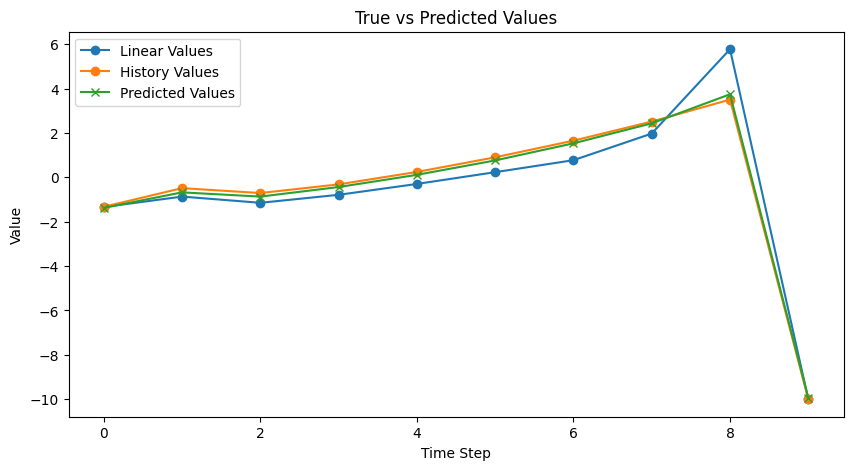

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[-1.000e-02 -2.000e-02 -2.000e-02 -1.000e-02 -1.000e-02 -0.000e+00 -0.000e+00  0.000e+00  2.000e-02 -1.003e+01]


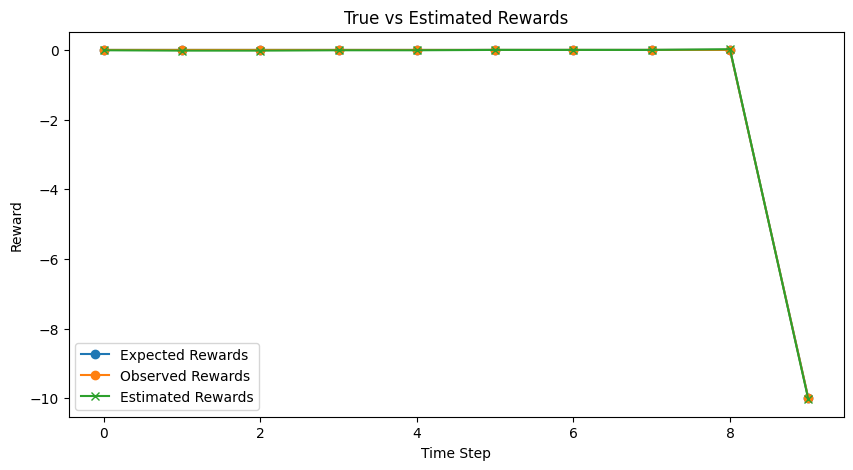

True Expected Rewards:
[ 0.    0.    0.    0.    0.    0.    0.    0.   -0.39]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[-0.05 -0.04  0.01 -0.02  0.06  0.02  0.03  0.08 -0.44]


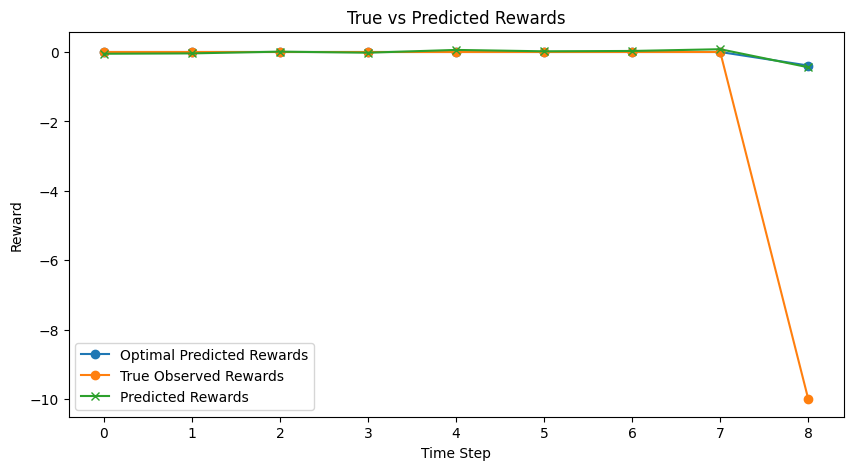

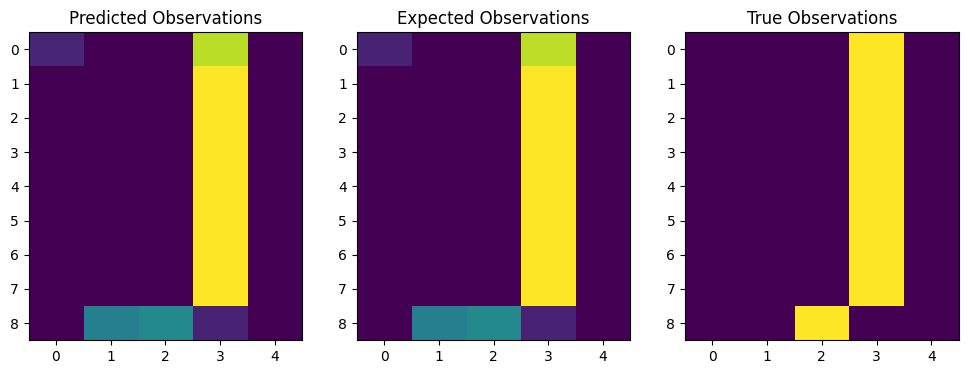

Linear Values:
[ -1.34  -1.34  -0.87  -1.15  -0.79  -0.3    0.23   0.77   0.23   0.84   2.24   5.29   7.3    8.59   8.04 -10.  ]
History Values:
[-1.33, -1.4, -0.59, -0.79, -0.44, 0.14, 0.83, 1.54, 0.34, 0.9, 2.07, 3.1, 3.64, 3.33, 7.14, nan]
Predicted Values:
[-1.38 -1.48 -0.6  -0.77 -0.42  0.11  0.74  1.5   0.67  1.36  2.27  5.01  5.63  7.22  6.84 -9.96]


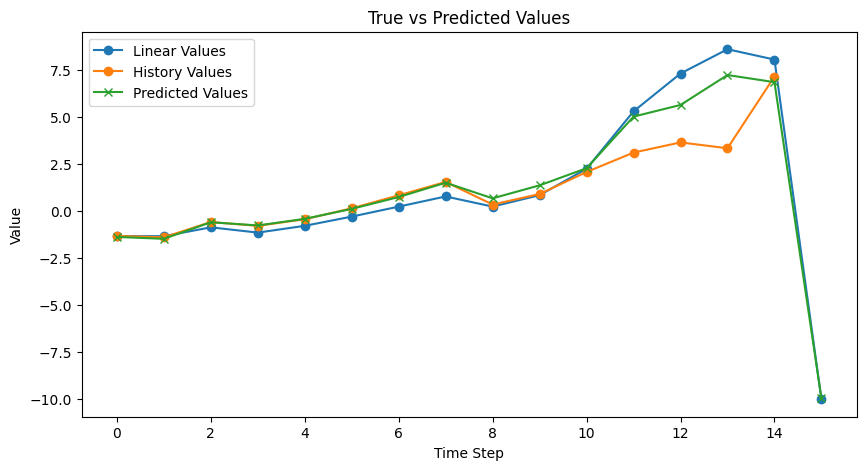

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[-0.01  0.01  0.03 -0.04 -0.02 -0.01 -0.01 -0.   -0.04 -0.01  0.05  0.04  0.01  0.02  0.06 -9.87]


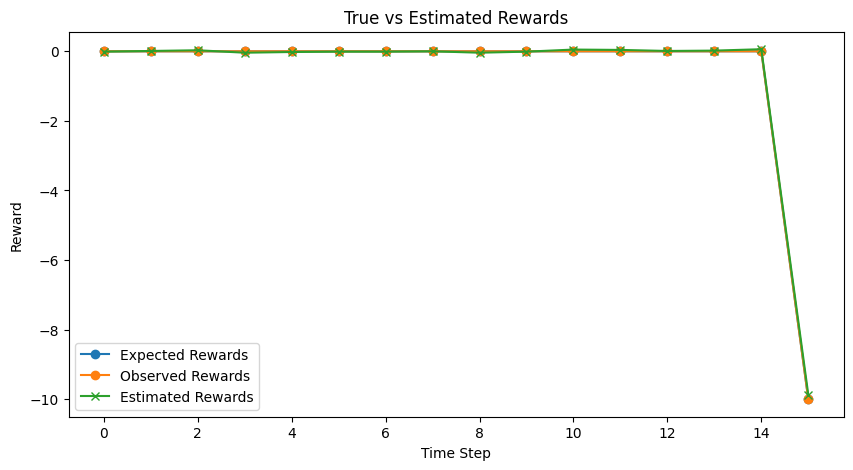

True Expected Rewards:
[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   5.26]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[ 0.02  0.02 -0.03 -0.03  0.02  0.06  0.03  0.1   0.02 -0.06  0.08  0.04  0.12  0.16  5.82]


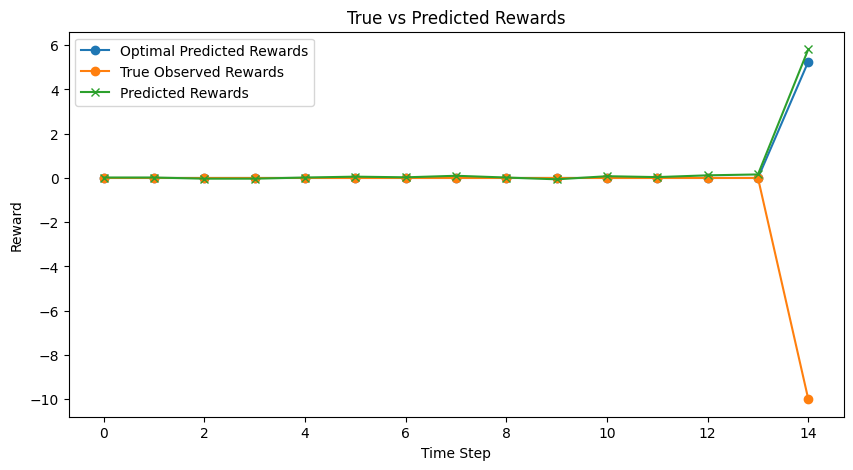

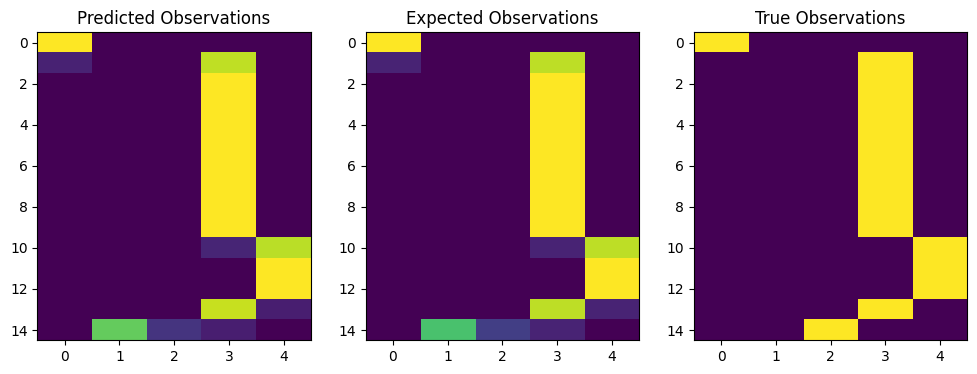

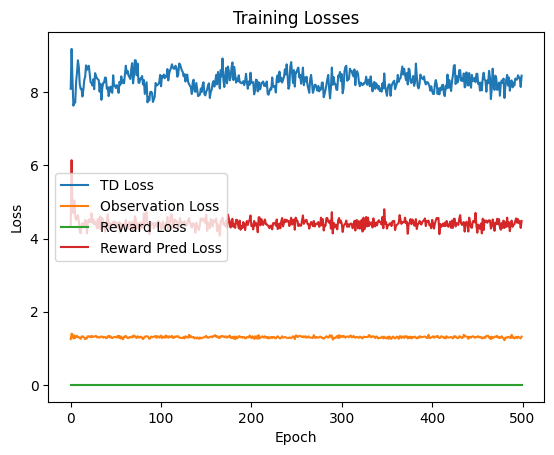

In [9]:
EPOCH = 500


for i in range(5):
    losses, models = train(
        models,
        episodes,
        num_epochs=EPOCH, gamma=1.0, lr=1e-3 * 0.9**i,  batch_size=2500,
        lambda_td=1.0, lambda_opl=10.0, lambda_rel=1.0, lambda_rpl=1.0, 
        )
    plot_validate(models, test_episodes, cliff, history_vtable, value_empirical)

    # Plot the training losses
    plot_train_losses(losses)




In [ ]:
w_vectors = []
device = next(belief_model.parameters()).device
with torch.no_grad():
    history = torch.tensor(test_episode.history, dtype=torch.float32).unsqueeze(0).to(device)  # shape: [1, T, D]

    z = belief_model(history)  # shape: [1, T]
    predicted_values = value_model(z)
    w_vectors.append(value_model.reveal_w(z).cpu().numpy())
    values = predicted_values.squeeze(0).cpu().numpy()  # shape: [T]

    values = np.round(values, 2)
    print(values)

w_vectors = np.array(w_vectors)[0,0]

plt.plot(w_vectors)
plt.show()

plt.figure(figsize = (10,5))
plt.imshow(w_vectors.T)

In [ ]:
all_belief_states = []
for episode in episodes.episodes:
    all_belief_states.append(np.array(episode.belief_states))
all_belief_states = np.concatenate(all_belief_states, axis=0)
belief_entropy = estimate_entropy(all_belief_states, base=np.e)

print(f"Average Entropy of Belief over states: {belief_entropy}:")


# Iterate over linear and non-linear decoders
for type in ['lin', 'nonlin']:
    if type == 'lin':
        print("Linear Decoder")
        belief_decoder = LinBeliefDecoder(input_dim=episodes.H, belief_dim=episodes.S)
    else:
        print("Non-Linear Decoder")
        belief_decoder = NonLinBeliefDecoder(input_dim=episodes.H, hidden_dim=64, belief_dim=episodes.S)

    belief_decoder, loss = decode_training(
        episodes, belief_decoder, [0, None], 
        value_RNN=None, num_epochs=5000, lr=1e-3)
    
    if type == 'lin':
        CEb_true_lin = loss
    else:
        CEb_true_nonlin = loss
    
    decode_visualisation(test_episode, belief_decoder, indices=[0,None], env_size = (3, 8), value_RNN=None)



In [ ]:
EPOCHS = np.arange(0, EPOCH, 500)

CEs_true_lin = []
CEs_true_nonlin = []
    
# Iterate over epochs
for epoch in EPOCHS:
    # Load the value RNN model from the checkpoint
    model_dict = torch.load(f"checkpoints/checkpoint_epoch_{epoch}.pth", weights_only=True)
    value_RNN.load_state_dict(model_dict['model_state_dict'])
    print(f"\nUsing Value RNN from epoch {epoch}")
    
    # Iterate over linear and non-linear decoders
    for type in ['lin', 'nonlin']:
        if type == 'lin':
            print("Linear Decoder")
            belief_decoder = LinBeliefDecoder(input_dim=value_RNN.latent_dim, belief_dim=episodes.S)
        else:
            print("Non-Linear Decoder")
            belief_decoder = NonLinBeliefDecoder(input_dim=value_RNN.latent_dim, hidden_dim=16, belief_dim=episodes.S)

        belief_decoder, loss = decode_training(
            episodes, belief_decoder, [0, None], 
            value_RNN=value_RNN, num_epochs=5000, lr=1e-3)
        
        if type == 'lin':
            CEs_true_lin.append(loss)
        else:
            CEs_true_nonlin.append(loss)

        if epoch == 0 or epoch == EPOCHS[-1]:
           decode_visualisation(test_episode, belief_decoder, [0, None], env_size = (3, 8), value_RNN=value_RNN)

estimated_KL_start_lin = [CEb_true_lin - belief_entropy]
estimated_KL_start_nonlin = [CEb_true_nonlin - belief_entropy]
estimated_KL_train_lin = [CEs_true_lin - belief_entropy]
estimated_KL_train_nonlin = [CEs_true_nonlin - belief_entropy]

plt.plot(EPOCHS, CEs_true_lin - belief_entropy, label='CE True Linear', marker='o')
plt.scatter(-100, CEb_true_lin - belief_entropy, color='red', marker='x')
plt.title("Cross-Entropy Loss for True Linear Belief Decoder")
plt.show()

plt.plot(EPOCHS, CEs_true_nonlin - belief_entropy, label='CE True Non-Linear', marker='o')
plt.scatter(-100, CEb_true_nonlin - belief_entropy, color='red', marker='x')
plt.title("Cross-Entropy Loss for True Non-Linear Belief Decoder")
plt.show()